In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (balanced_accuracy_score,
    matthews_corrcoef, confusion_matrix, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shared.config import *
from shared.metrics import ids_evaluate, tune_threshold
from shared.plots import (plot_confusion_matrix,
                           plot_metrics_bar, plot_frontier)

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

In [3]:
# Cell 2 — Load splits
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Train: (5798977, 78)
Val  : (1242638, 78)
Test : (1242639, 78)


In [4]:
# Cell 3 — Scaling + subsampling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

rng = np.random.RandomState(RANDOM_STATE)

# KNN subsample
idx_knn  = rng.choice(len(X_train), SAMPLE_KNN, replace=False)
X_tr_knn = X_train_sc[idx_knn]
y_tr_knn = y_train.iloc[idx_knn].values

# SVM subsample
idx_svm  = rng.choice(len(X_train), SAMPLE_SVM, replace=False)
X_tr_svm = X_train_sc[idx_svm]
y_tr_svm = y_train.iloc[idx_svm].values

# NB subsample
idx_nb   = rng.choice(len(X_train), SAMPLE_NB, replace=False)
X_tr_nb  = X_train_sc[idx_nb]
y_tr_nb  = y_train.iloc[idx_nb].values

with open("models/ml/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved")

Scaler saved


In [5]:
# Cell 4 — Training loop
def train_and_evaluate(name, clf, X_tr, y_tr,
                        X_te, y_te, X_v, y_v,
                        needs_proba=True):
    print(f"\nTraining {name}...")
    start = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - start
    print(f"  Done in {train_time:.1f}s")

    if needs_proba:
        th = tune_threshold(clf, X_v, y_v)
        proba_te = clf.predict_proba(X_te)[:, 1]
        y_pred   = (proba_te >= th).astype(int)
    else:
        proba_te = None
        y_pred   = clf.predict(X_te)
        th       = None

    m = ids_evaluate(name, y_te, proba_te, y_pred, th)
    m["Train Time (s)"] = round(train_time, 2)
    m["Threshold"]      = round(th, 4) if th else "N/A"

    # Save model
    path = f"models/ml/{name.lower().replace(' ','_')}.pkl"
    with open(path, "wb") as f:
        pickle.dump(clf, f)

    # Print metrics
    for k, v in m.items():
        print(f"  {k}: {v}")

    return m, clf, proba_te, y_pred

all_results = {}
all_probas  = {}
all_preds   = {}
trained     = {}

In [7]:
# Cell 5 — Random Forest
m, clf, proba, pred = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, n_jobs=-1,
                            random_state=RANDOM_STATE),
    X_train, y_train.values,
    X_test,  y_test.values,
    X_val,   y_val.values
)
all_results["Random Forest"] = m
all_probas["Random Forest"]  = proba
all_preds["Random Forest"]   = pred
trained["rf"] = clf


Training Random Forest...
  Done in 890.7s
  Model: Random Forest
  Balanced Acc: 0.9562
  F1 Macro: 0.9482
  MCC: 0.8971
  Attack Recall: 0.9497
  Benign Recall: 0.9627
  Attack Precision: 0.9004
  Benign Precision: 0.9818
  FAR: 0.0373
  FNR: 0.0503
  ROC-AUC: 0.9855
  PR-AUC: 0.9788
  Train Time (s): 890.69
  Threshold: 0.1733


In [9]:
# Cell 6 — Decision Tree
m, clf, proba, pred = train_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=12,
                            random_state=RANDOM_STATE),
    X_train, y_train.values,
    X_test,  y_test.values,
    X_val,   y_val.values
)
all_results["Decision Tree"] = m
all_probas["Decision Tree"]  = proba
all_preds["Decision Tree"]   = pred


Training Decision Tree...
  Done in 131.9s
  Model: Decision Tree
  Balanced Acc: 0.9642
  F1 Macro: 0.9625
  MCC: 0.9251
  Attack Recall: 0.95
  Benign Recall: 0.9784
  Attack Precision: 0.9397
  Benign Precision: 0.9822
  FAR: 0.0216
  FNR: 0.05
  ROC-AUC: 0.9894
  PR-AUC: 0.9804
  Train Time (s): 131.9
  Threshold: 0.1198


In [11]:
# Cell 7 — KNN (subsampled)
m, clf, proba, pred = train_and_evaluate(
    "KNN",
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_tr_knn, y_tr_knn,
    X_test_sc, y_test.values,
    X_val_sc,  y_val.values
)
all_results["KNN"] = m
all_probas["KNN"]  = proba
all_preds["KNN"]   = pred


Training KNN...
  Done in 0.0s
  Model: KNN
  Balanced Acc: 0.9337
  F1 Macro: 0.9064
  MCC: 0.8205
  Attack Recall: 0.9561
  Benign Recall: 0.9113
  Attack Precision: 0.793
  Benign Precision: 0.9832
  FAR: 0.0887
  FNR: 0.0439
  ROC-AUC: 0.975
  PR-AUC: 0.9628
  Train Time (s): 0.0
  Threshold: 0.2


In [12]:
# Cell 8 — Naive Bayes (subsampled)
m, clf, proba, pred = train_and_evaluate(
    "Naive Bayes",
    GaussianNB(),
    X_tr_nb, y_tr_nb,
    X_test_sc, y_test.values,
    X_val_sc,  y_val.values
)
all_results["Naive Bayes"] = m
all_probas["Naive Bayes"]  = proba
all_preds["Naive Bayes"]   = pred


Training Naive Bayes...
  Done in 0.0s
  Model: Naive Bayes
  Balanced Acc: 0.8129
  F1 Macro: 0.7309
  MCC: 0.5506
  Attack Recall: 0.9498
  Benign Recall: 0.6759
  Attack Precision: 0.5101
  Benign Precision: 0.9743
  FAR: 0.3241
  FNR: 0.0502
  ROC-AUC: 0.8875
  PR-AUC: 0.6816
  Train Time (s): 0.03
  Threshold: 0.0


In [13]:
# Cell 9 — SVM (subsampled)
m, clf, proba, pred = train_and_evaluate(
    "SVM",
    SVC(kernel="rbf", C=1.0, gamma="scale",
        probability=True, random_state=RANDOM_STATE),
    X_tr_svm, y_tr_svm,
    X_test_sc, y_test.values,
    X_val_sc,  y_val.values
)
all_results["SVM"] = m
all_probas["SVM"]  = proba
all_preds["SVM"]   = pred


Training SVM...
  Done in 1355.9s
  Model: SVM
  Balanced Acc: 0.8744
  F1 Macro: 0.8176
  MCC: 0.6732
  Attack Recall: 0.9493
  Benign Recall: 0.7995
  Attack Precision: 0.6272
  Benign Precision: 0.978
  FAR: 0.2005
  FNR: 0.0507
  ROC-AUC: 0.9707
  PR-AUC: 0.9628
  Train Time (s): 1355.93
  Threshold: 0.0457


In [14]:
# Cell 10 — XGBoost baseline
m, clf, proba, pred = train_and_evaluate(
    "XGBoost",
    XGBClassifier(n_estimators=500, max_depth=8,
                   learning_rate=0.05, subsample=0.8,
                   colsample_bytree=0.8,
                   objective="binary:logistic",
                   eval_metric="logloss",
                   tree_method="hist",
                   random_state=RANDOM_STATE),
    X_train, y_train.values,
    X_test,  y_test.values,
    X_val,   y_val.values
)
all_results["XGBoost"] = m
all_probas["XGBoost"]  = proba
all_preds["XGBoost"]   = pred
trained["xgb_base"] = clf


Training XGBoost...
  Done in 116.9s
  Model: XGBoost
  Balanced Acc: 0.9661
  F1 Macro: 0.9665
  MCC: 0.9329
  Attack Recall: 0.9494
  Benign Recall: 0.9828
  Attack Precision: 0.9516
  Benign Precision: 0.982
  FAR: 0.0172
  FNR: 0.0506
  ROC-AUC: 0.9927
  PR-AUC: 0.9868
  Train Time (s): 116.94
  Threshold: 0.1867


In [15]:
# Cell 11 — LightGBM
m, clf, proba, pred = train_and_evaluate(
    "LightGBM",
    LGBMClassifier(n_estimators=500, learning_rate=0.05,
                    num_leaves=63, n_jobs=-1,
                    random_state=RANDOM_STATE),
    X_train, y_train.values,
    X_test,  y_test.values,
    X_val,   y_val.values
)
all_results["LightGBM"] = m
all_probas["LightGBM"]  = proba
all_preds["LightGBM"]   = pred
trained["lgbm"] = clf


Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1520472, number of negative: 4278505
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13946
[LightGBM] [Info] Number of data points in the train set: 5798977, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.262197 -> initscore=-1.034583
[LightGBM] [Info] Start training from score -1.034583
  Done in 72.1s
  Model: LightGBM
  Balanced Acc: 0.9661
  F1 Macro: 0.9664
  MCC: 0.9329
  Attack Recall: 0.9495
  Benign Recall: 0.9828
  Attack Precision: 0.9514
  Benign Precision: 0.9821
  FAR: 0.0172
  FNR: 0.0505
  ROC-AUC: 0.9925
  PR-AUC: 0.9865
  Train Time (s): 72.07
  Threshold: 0.1887


In [16]:
# Cell 12 — Summary table
results_df = pd.DataFrame(list(all_results.values()))
results_df = results_df.sort_values(
    "Balanced Acc", ascending=False).reset_index(drop=True)

print("\nML MODEL COMPARISON (sorted by Balanced Accuracy):")
print("=" * 80)
print(results_df[[
    "Model","Balanced Acc","F1 Macro","MCC",
    "Attack Recall","Benign Recall","FAR","ROC-AUC"
]].to_string(index=False))

results_df.to_csv("outputs/reports/02_ml_results.csv",
                   index=False)
print("\nSaved to outputs/reports/02_ml_results.csv")


ML MODEL COMPARISON (sorted by Balanced Accuracy):
        Model  Balanced Acc  F1 Macro    MCC  Attack Recall  Benign Recall    FAR  ROC-AUC
     LightGBM        0.9661    0.9664 0.9329         0.9495         0.9828 0.0172   0.9925
      XGBoost        0.9661    0.9665 0.9329         0.9494         0.9828 0.0172   0.9927
Decision Tree        0.9642    0.9625 0.9251         0.9500         0.9784 0.0216   0.9894
Random Forest        0.9562    0.9482 0.8971         0.9497         0.9627 0.0373   0.9855
          KNN        0.9337    0.9064 0.8205         0.9561         0.9113 0.0887   0.9750
          SVM        0.8744    0.8176 0.6732         0.9493         0.7995 0.2005   0.9707
  Naive Bayes        0.8129    0.7309 0.5506         0.9498         0.6759 0.3241   0.8875

Saved to outputs/reports/02_ml_results.csv


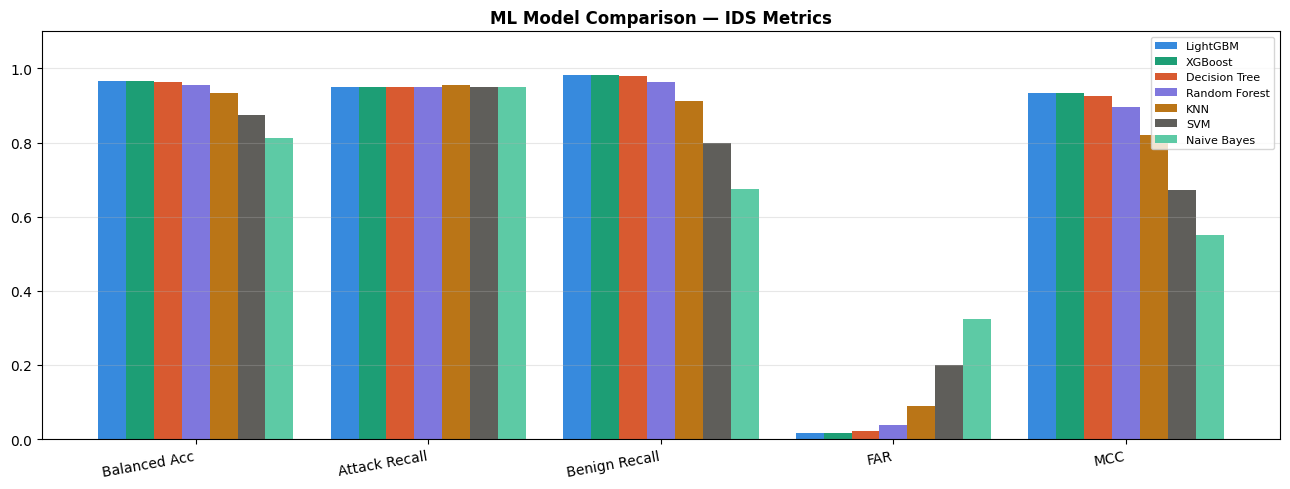

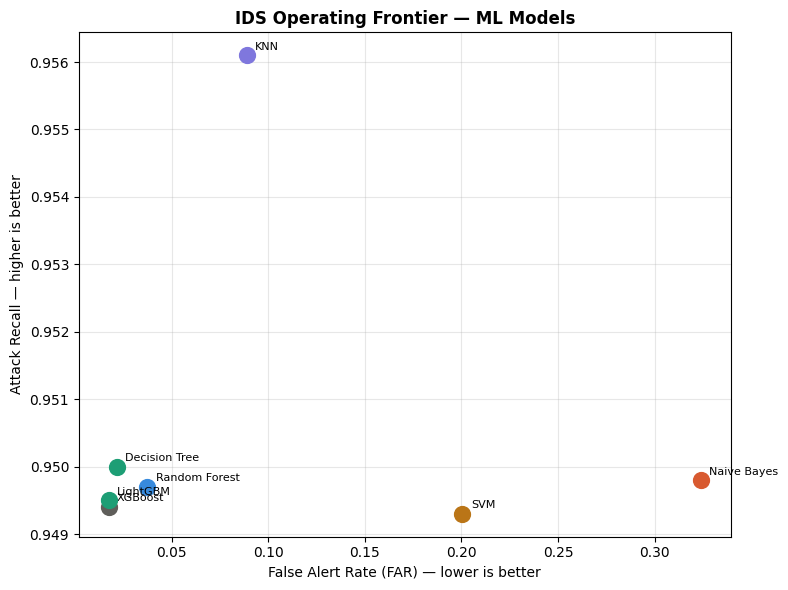

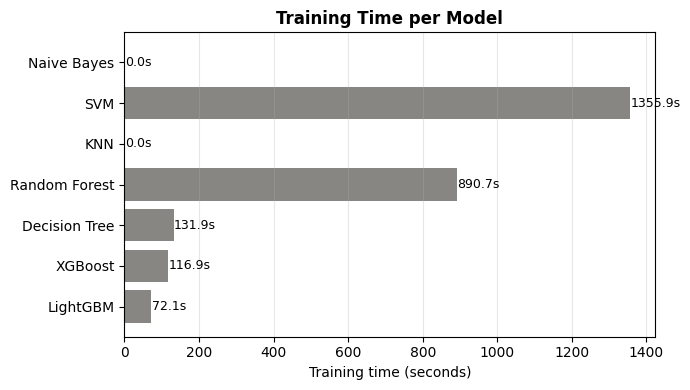

In [17]:
# Cell 13 — Graphs
KEY_METRICS = ["Balanced Acc","Attack Recall",
               "Benign Recall","FAR","MCC"]

# Grouped bar
x = np.arange(len(KEY_METRICS))
w = 0.12
models_list = results_df["Model"].tolist()
palette = ["#378ADD","#1D9E75","#D85A30",
           "#7F77DD","#BA7517","#5F5E5A","#5DCAA5"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, model in enumerate(models_list):
    row  = all_results[model]
    vals = [row[k] for k in KEY_METRICS]
    off  = (i - len(models_list)/2 + 0.5) * w
    ax.bar(x + off, vals, w, label=model,
           color=palette[i % len(palette)])

ax.set_xticks(x)
ax.set_xticklabels(KEY_METRICS, rotation=10, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("ML Model Comparison — IDS Metrics",
             fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/02_ml_comparison.png", dpi=150)
plt.show()

# Operating frontier
plot_frontier(
    all_results,
    title="IDS Operating Frontier — ML Models",
    save_path="outputs/graphs/02_ids_frontier_ml.png"
)

# Training time
train_times  = [all_results[m]["Train Time (s)"]
                for m in models_list]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(models_list, train_times,
               color="#5F5E5A", alpha=0.75)
for bar, t in zip(bars, train_times):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", fontsize=9)
ax.set_xlabel("Training time (seconds)")
ax.set_title("Training Time per Model", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/02_train_time.png", dpi=150)
plt.show()

In [18]:
# Cell 14 — Save all results for next notebooks
with open("models/ml/all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)
with open("models/ml/all_probas.pkl", "wb") as f:
    pickle.dump(all_probas, f)
with open("models/ml/trained_models.pkl", "wb") as f:
    pickle.dump(trained, f)

print("Notebook 02 complete — proceed to 03_optimization.ipynb")

Notebook 02 complete — proceed to 03_optimization.ipynb
